# RSNA 2024 Data preprocessing

## Packages and WD

In [8]:
# Used packages 
import opendatasets as od
import pandas as pd
import shutil, json, zipfile, random, math
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import pydicom
from pathlib import Path
from IPython.display import clear_output
from sklearn.model_selection import train_test_split

import cv2
from PIL import Image
import torchvision.transforms as transforms

import plotly.offline as pyo
from scipy.interpolate import griddata
import plotly.offline as pyo
from scipy.interpolate import griddata
import plotly.graph_objects as go

In [9]:
import os
# Set the working directory
os.chdir("/home/jupyter-lukj08@vse.cz/VSE_bachelor_thesis_lumbar_spine_degeneration_classification")
print(os.getcwd())


/home/jupyter-lukj08@vse.cz/VSE_bachelor_thesis_lumbar_spine_degeneration_classification


## Data import

In [10]:
path = "./BC-data/data-rsna2024"
train_data = pd.read_csv("./BC-data/data-rsna2024/train.csv")
train_label = pd.read_csv("./BC-data/data-rsna2024/train_label_coordinates.csv")
train_des = pd.read_csv("./BC-data/data-rsna2024/train_series_descriptions.csv")
sub_des = pd.read_csv("./BC-data/data-rsna2024/test_series_descriptions.csv")
sample_sub = pd.read_csv("./BC-data/data-rsna2024/sample_submission.csv")
data_merged = pd.read_csv("./BC-data/data-rsna2024/data_merged.csv")
display(data_merged.head())

,row_id,study_id,series_id,condition,level,series_description,instance_number,x,y,severity,img_path
0,4003253_spinal_canal_stenosis_l1_l2,4003253,702807833,Spinal Canal Stenosis,L1/L2,Sagittal T2/STIR,8,322.831858,227.964602,Normal/Mild,./BC-data/data-rsna2024/train_images/4003253/7...
1,4003253_spinal_canal_stenosis_l2_l3,4003253,702807833,Spinal Canal Stenosis,L2/L3,Sagittal T2/STIR,8,320.571429,295.714286,Normal/Mild,./BC-data/data-rsna2024/train_images/4003253/7...
2,4003253_spinal_canal_stenosis_l3_l4,4003253,702807833,Spinal Canal Stenosis,L3/L4,Sagittal T2/STIR,8,323.030303,371.818182,Normal/Mild,./BC-data/data-rsna2024/train_images/4003253/7...
3,4003253_spinal_canal_stenosis_l4_l5,4003253,702807833,Spinal Canal Stenosis,L4/L5,Sagittal T2/STIR,8,335.292035,427.327434,Normal/Mild,./BC-data/data-rsna2024/train_images/4003253/7...
4,4003253_spinal_canal_stenosis_l5_s1,4003253,702807833,Spinal Canal Stenosis,L5/S1,Sagittal T2/STIR,8,353.415929,483.964602,Normal/Mild,./BC-data/data-rsna2024/train_images/4003253/7...


# Preparing the data for model

## Split into train-validate-test
* We need to maintain all images (observations) belonging to same id together in the same folder. 
* Group by 'study_id' and split these groups.
* Split study IDs into train, validate, and test sets.
* We will use 70% train, 30% for splitting into val and test. 

In [11]:
# Group by study_id
study_ids = data_merged["study_id"].unique()

# Split study IDs
train_ids, test_ids = train_test_split(study_ids, test_size=0.30, random_state=42)  
val_ids, test_ids = train_test_split(test_ids, test_size=0.50, random_state=42)   

# Append all corresponding observations 
train_df = data_merged[data_merged['study_id'].isin(train_ids)]
val_df = data_merged[data_merged['study_id'].isin(val_ids)]
test_df = data_merged[data_merged['study_id'].isin(test_ids)]

# The sizes of the splits
print("Training Data Size: ", train_df.shape[0])
print("Validation Data Size: ", val_df.shape[0])
print("Test Data Size: ", test_df.shape[0])
print("Number of observations: ", len(data_merged["study_id"]))

Training Data Size:  34070
Validation Data Size:  7306
Test Data Size:  7316
Number of observations:  48692


Text(0.5, 1.0, 'Distribution of Severity in Test Data')

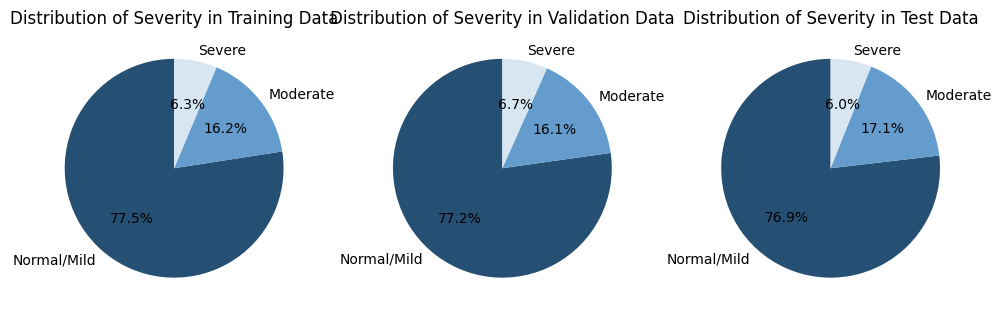

In [12]:
# Create subplot layout
fig, axes = plt.subplots(1, 3, figsize=(12, 8))

# Severity distribution for the Training Data
severity_counts_train = train_df['severity'].value_counts()
axes[0].pie(severity_counts_train, labels=severity_counts_train.index, autopct='%1.1f%%', startangle=90, colors=['#254f73', '#649dcd', '#d8e6f2'])
axes[0].set_title('Distribution of Severity in Training Data')

# Severity distribution for the Validation Data
severity_counts_val = val_df['severity'].value_counts()
axes[1].pie(severity_counts_val, labels=severity_counts_val.index, autopct='%1.1f%%', startangle=90, colors=['#254f73', '#649dcd', '#d8e6f2'])
axes[1].set_title('Distribution of Severity in Validation Data')

# Severity distribution for the Test Data
severity_counts_test = test_df['severity'].value_counts()
axes[2].pie(severity_counts_test, labels=severity_counts_test.index, autopct='%1.1f%%', startangle=90, colors=['#254f73', '#649dcd', '#d8e6f2'])
axes[2].set_title('Distribution of Severity in Test Data')

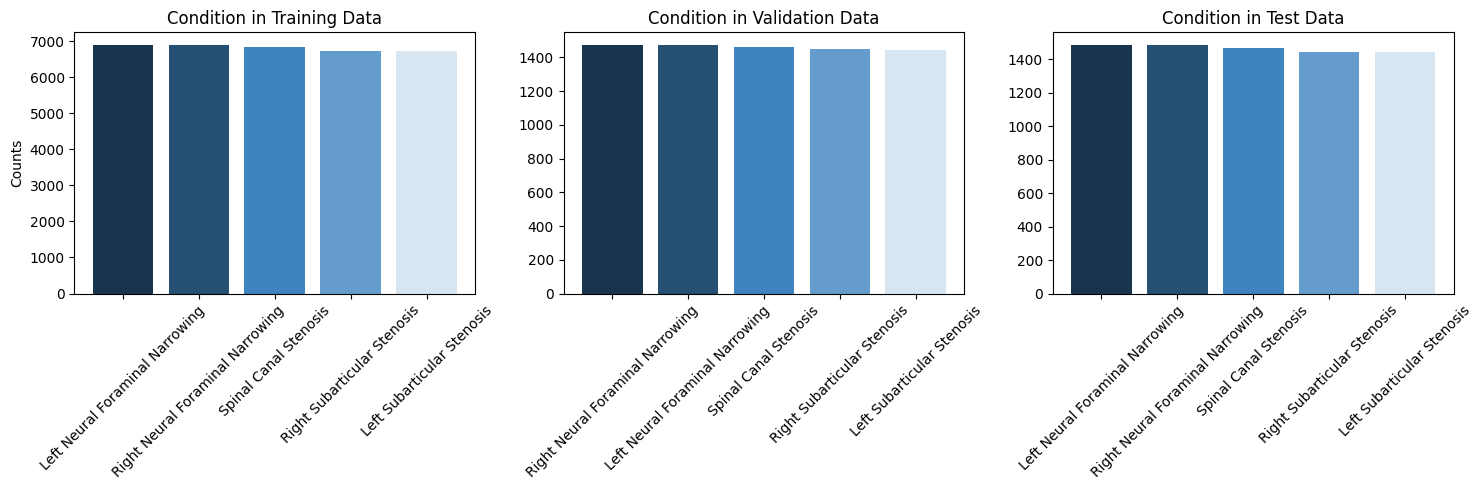

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5)) 

# Training data
condition_counts_train = train_df['condition'].value_counts()
axes[0].bar(condition_counts_train.index, condition_counts_train.values, color=['#18354d','#254f73','#3e85c0', '#649dcd', '#d8e6f2'])
axes[0].set_title('Condition in Training Data')
axes[0].set_ylabel('Counts')
axes[0].set_xticks(range(len(condition_counts_train.index)))
axes[0].set_xticklabels(condition_counts_train.index, rotation=45) 

# Validation data
condition_counts_val = val_df['condition'].value_counts()
axes[1].bar(condition_counts_val.index, condition_counts_val.values, color=['#18354d','#254f73','#3e85c0', '#649dcd', '#d8e6f2'])
axes[1].set_title('Condition in Validation Data')
axes[1].set_xticks(range(len(condition_counts_val.index)))
axes[1].set_xticklabels(condition_counts_val.index, rotation=45) 

# Test data
condition_counts_test = test_df['condition'].value_counts()
axes[2].bar(condition_counts_test.index, condition_counts_test.values, color=['#18354d','#254f73','#3e85c0', '#649dcd', '#d8e6f2'])
axes[2].set_title('Condition in Test Data')
axes[2].set_xticks(range(len(condition_counts_test.index))) 
axes[2].set_xticklabels(condition_counts_test.index, rotation=45)

plt.tight_layout()
plt.show()


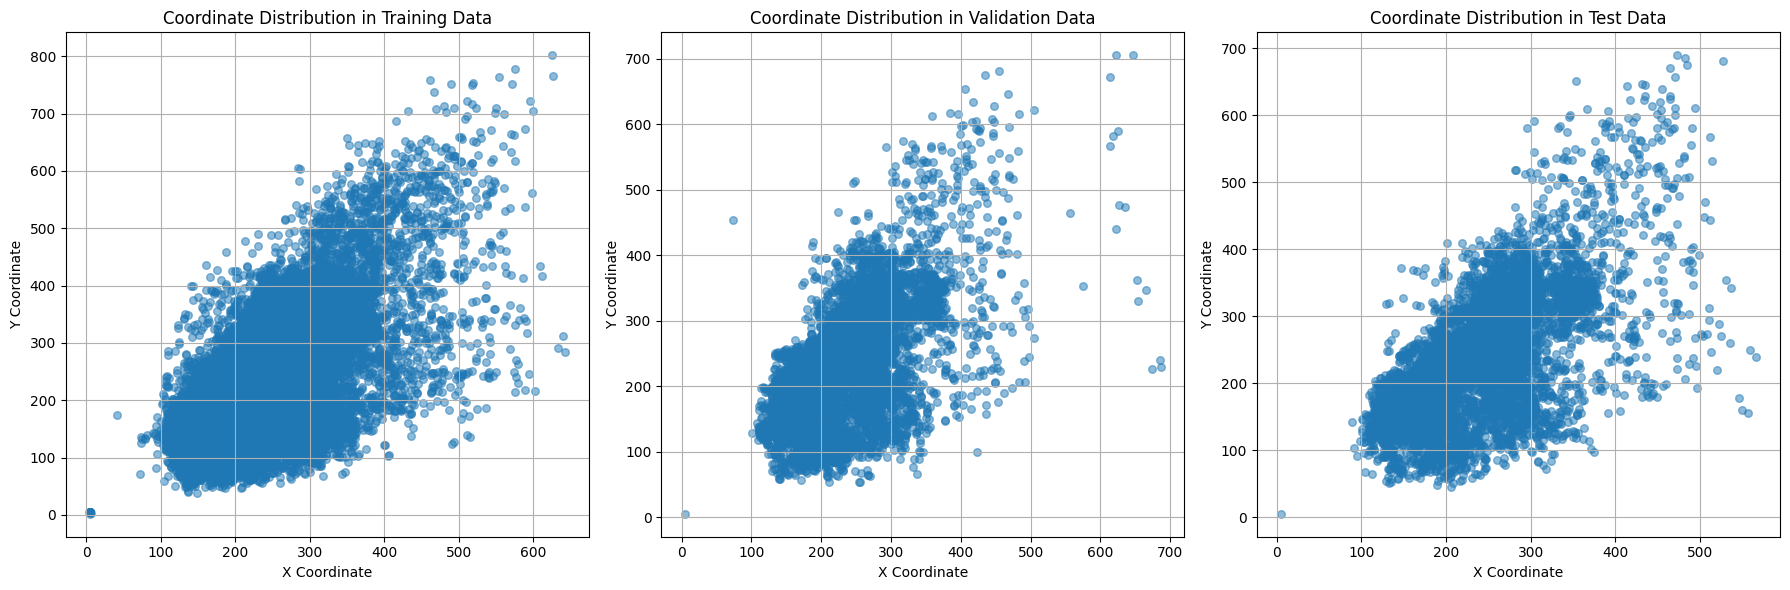

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Scatter Plot for Training Data
axes[0].scatter(train_df['x'], train_df['y'], alpha=0.5, s=30)
axes[0].set_title('Coordinate Distribution in Training Data')
axes[0].set_xlabel('X Coordinate')
axes[0].set_ylabel('Y Coordinate')
axes[0].grid(True)

# Scatter Plot for Validation Data
axes[1].scatter(val_df['x'], val_df['y'], alpha=0.5, s=30)
axes[1].set_title('Coordinate Distribution in Validation Data')
axes[1].set_xlabel('X Coordinate')
axes[1].set_ylabel('Y Coordinate')
axes[1].grid(True)

# Scatter Plot for Test Data
axes[2].scatter(test_df['x'], test_df['y'], alpha=0.5, s=30)
axes[2].set_title('Coordinate Distribution in Test Data')
axes[2].set_xlabel('X Coordinate')
axes[2].set_ylabel('Y Coordinate')
axes[2].grid(True)

# Adjust layout and display the plot
plt.tight_layout()
plt.show()
